# Recipe Clustering V12 – Improved Feature Engineering

Testing two improvements over the best-performing baseline (Model-2, α=0, k=7, Jaccard=2.956):

| # | Approach | Feature space |
|---|---|---|
| **Baseline** | Model-2, OT1 Grandfamilien | 9 dims |
| **Option 4** | Filtered ingredient matrix + PCA | 69 ingredients → PCA |
| **Option 5** | Hybrid: OT1 + filtered ingredient PCA | 9 + PCA dims concatenated |

**Ingredient filter:** keep only ingredients appearing in ≥ 3 recipes (69 of 203).  
**Best k** tested per approach by maximising Jaccard against the hand-drawn reference.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import faiss

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Ready ✓')

Ready ✓


## 1. Load & Preprocess

In [2]:
df_raw = pd.read_csv('../data/gold/Versuchsdaten_3_1.csv')
ign    = pd.read_csv('../data/gold/ignone_substances.csv')
cas    = pd.read_csv('../data/gold/CAS Nummern.csv', header=13)

ign_cas = ign[['Ident']].merge(
    cas[['Ident.','CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.':'Ident'}),
    on='Ident', how='left')
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0
per = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per > 0, df['Totalmenge'] / per, df['Totalmenge'])
assert df.groupby('Rez.-Nr.')['Totalmenge'].sum().round(6).eq(1.0).all()

recipes = df['Rez.-Nr.'].unique().tolist()
OT1     = 'Odour Type 1 FlavourWheel'
print(f'Recipes: {len(recipes)},  active rows: {(df["Totalmenge"]>0).sum()}')

Recipes: 24,  active rows: 602


## 2. Shared Helpers

In [3]:
REFERENCE = {
    'Karamell'    : {'186.277P','187.800P','187.916P','185.237H','188.740P'},
    'Grün'        : {'185.091','185.309P','188.412P','185.090P','187.657P','185.675P'},
    'Walderdbeer' : {'187.796P','185.267','185.471','185.382P','187.886P','187.507P','187.894P','186.190P'},
    'Isolated'    : {'185.028'},
    'Transitional': {'187.694P','185.507P','185.294','187.787P'},
}

def jaccard_total(labels):
    clusters = {l: {r for r,lb in zip(recipes,labels) if lb==l} for l in set(labels)}
    total = 0.0
    for ref in REFERENCE.values():
        best = max(
            (len(ref & cs) / len(ref | cs) if (ref | cs) else 0)
            for cs in clusters.values()
        )
        total += best
    return round(total, 3)

def jaccard_breakdown(labels):
    clusters = {l: {r for r,lb in zip(recipes,labels) if lb==l} for l in set(labels)}
    rows = []
    for name, ref in REFERENCE.items():
        best_j, best_cn, best_sh = 0, None, set()
        for cn, cs in clusters.items():
            sh = ref & cs
            j  = len(sh)/len(ref|cs) if (ref|cs) else 0
            if j > best_j:
                best_j, best_cn, best_sh = j, cn, sh
        rows.append((name, round(best_j,3), best_cn, best_sh, ref - best_sh))
    return rows

def run_all_k(xf, k_range=(3,12)):
    """Try every k, return list of (k, silhouette, jaccard, labels)."""
    results = []
    for k in range(k_range[0], min(k_range[1]+1, len(recipes))):
        km = faiss.Kmeans(xf.shape[1], k, niter=50, verbose=False, seed=42)
        km.train(xf)
        _, lbl = km.index.search(xf, 1)
        lbl = lbl.flatten()
        sil = silhouette_score(xf, lbl) if len(set(lbl))>1 else -1
        j   = jaccard_total(lbl)
        results.append((k, sil, j, lbl.copy()))
    return results

def print_k_table(results, label=''):
    print(f"\n{'k':>3}  {'Silhouette':>10}  {'Jaccard':>8}  Cluster sizes")
    print('-'*55)
    best_j = max(r[2] for r in results)
    for k, sil, j, lbl in results:
        sizes  = sorted([int((lbl==l).sum()) for l in set(lbl)], reverse=True)
        marker = '  <-- best Jaccard' if j == best_j else ''
        print(f"{k:>3}  {sil:>10.4f}  {j:>8.3f}  {sizes}{marker}")

def print_breakdown(labels, title):
    bd    = jaccard_breakdown(labels)
    total = sum(r[1] for r in bd)
    print(f'\n{"="*60}')
    print(f'{title}  –  Total Jaccard: {total:.3f}')
    print('='*60)
    for name, j, cn, shared, missing in bd:
        print(f'  {name:15s}  J={j:.3f}  C{cn}  shared={sorted(shared)}')
        if missing: print(f'  {"":15s}         missing={sorted(missing)}')

print('Helpers defined ✓')

Helpers defined ✓


## 3. Baseline – Model-2 at k=7 (reference point)

In [4]:
def norm_term(t):
    if pd.isna(t) or not isinstance(t, str): return None
    t = t.lower().strip().replace('"','').replace("'",'').rstrip('.,;:')
    return t if len(t)>=2 else None

VOCAB = sorted({norm_term(v) for v in df[OT1].dropna() if norm_term(v)})
VI    = {t:i for i,t in enumerate(VOCAB)}

def build_ot1_vectors():
    vecs = np.zeros((len(recipes), len(VOCAB)))
    for rec_i, rec in enumerate(recipes):
        for _, row in df[(df['Rez.-Nr.']==rec) & (df['Totalmenge']>0)].iterrows():
            term = norm_term(row.get(OT1))
            if term and term in VI:
                vecs[rec_i, VI[term]] += row['Totalmenge']
    return normalize(vecs)

X_ot1 = build_ot1_vectors()
xf_ot1 = np.ascontiguousarray(X_ot1.astype('float32'))

res_baseline = run_all_k(xf_ot1)
print('BASELINE – Model-2 (OT1 Grandfamilien, α=0)')
print_k_table(res_baseline)

# Best by Jaccard
_, _, j_base, lbl_base = max(res_baseline, key=lambda x: x[2])
k_base = next(k for k,_,j,_ in res_baseline if j==j_base)
print_breakdown(lbl_base, f'Baseline k={k_base}')

BASELINE – Model-2 (OT1 Grandfamilien, α=0)

  k  Silhouette   Jaccard  Cluster sizes
-------------------------------------------------------
  3      0.2893     1.956  [9, 8, 7]
  4      0.2075     1.670  [9, 8, 5, 2]
  5      0.2662     1.538  [8, 7, 5, 2, 2]
  6      0.2627     2.001  [7, 6, 5, 2, 2, 2]
  7      0.2283     2.956  [6, 5, 5, 3, 2, 2, 1]  <-- best Jaccard
  8      0.2723     2.928  [6, 5, 4, 3, 2, 2, 1, 1]
  9      0.2422     2.467  [5, 5, 3, 3, 2, 2, 2, 1, 1]
 10      0.2108     1.773  [6, 3, 3, 2, 2, 2, 2, 2, 1, 1]
 11      0.1844     1.656  [5, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1]
 12      0.1848     1.633  [4, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1]

Baseline k=7  –  Total Jaccard: 2.956
  Karamell         J=0.429  C1  shared=['185.237H', '186.277P', '188.740P']
                          missing=['187.800P', '187.916P']
  Grün             J=0.333  C2  shared=['185.091', '187.657P', '188.412P']
                          missing=['185.090P', '185.309P', '185.675P']
  Walderdbeer  

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


## 4. Option 4 – Filtered Ingredient Matrix + PCA

Keep only ingredients present in ≥ 3 recipes (69 of 203), then reduce with PCA.

In [5]:
MIN_RECIPES = 3

pivot_full = (
    df[df['Totalmenge']>0]
    .pivot_table(index='Rez.-Nr.', columns='Name', values='Totalmenge', aggfunc='sum')
    .reindex(recipes)
    .fillna(0.0)
)

# Filter ingredients
recipe_count   = (pivot_full > 0).sum(axis=0)
kept_ingr      = recipe_count[recipe_count >= MIN_RECIPES].index.tolist()
pivot_filtered = pivot_full[kept_ingr]
X_ingr         = pivot_filtered.values

print(f'Ingredients kept (>= {MIN_RECIPES} recipes): {len(kept_ingr)} of {len(recipe_count)}')
print(f'Matrix shape: {X_ingr.shape}')
print(f'Sparsity: {(X_ingr==0).mean()*100:.1f}% zeros')

# Scree to pick n_components
pca_full = PCA().fit(X_ingr)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_) * 100
n80      = int(np.argmax(cumvar >= 80)) + 1
print(f'\nPCA components to reach 80% variance: {n80}')
print(f'Variance per PC (first 10): {[round(v*100,1) for v in pca_full.explained_variance_ratio_[:10]]}')

Ingredients kept (>= 3 recipes): 69 of 203
Matrix shape: (24, 69)
Sparsity: 73.6% zeros

PCA components to reach 80% variance: 7
Variance per PC (first 10): [np.float64(36.3), np.float64(13.5), np.float64(10.1), np.float64(9.0), np.float64(5.5), np.float64(4.8), np.float64(4.2), np.float64(3.6), np.float64(2.7), np.float64(2.2)]


In [6]:
# Test multiple n_components values
print('Option 4 – Filtered Ingredient PCA  (best Jaccard per n_components)\n')
print(f'  {"n_pca":>6}  {"var_expl":>9}  {"best_k":>6}  {"Jaccard":>8}')
print('  ' + '-'*36)

opt4_results = {}
for n_pca in [3, 5, 8, 10, 12, 15, n80]:
    n_pca = min(n_pca, len(recipes)-1, len(kept_ingr))
    pca_n = PCA(n_components=n_pca)
    X_pca = pca_n.fit_transform(X_ingr)
    var   = pca_n.explained_variance_ratio_.sum() * 100
    X_norm= normalize(X_pca)
    xf    = np.ascontiguousarray(X_norm.astype('float32'))
    res   = run_all_k(xf)
    best  = max(res, key=lambda x: x[2])
    opt4_results[n_pca] = (best, res, pca_n)
    print(f'  {n_pca:>6}  {var:>8.1f}%  {best[0]:>6}  {best[2]:>8.3f}')

# Best overall
best_n4 = max(opt4_results, key=lambda n: opt4_results[n][0][2])
best_result4 = opt4_results[best_n4][0]
print(f'\nBest: n_pca={best_n4}, k={best_result4[0]}, Jaccard={best_result4[2]:.3f}')

Option 4 – Filtered Ingredient PCA  (best Jaccard per n_components)

   n_pca   var_expl  best_k   Jaccard
  ------------------------------------
       3      59.9%      12     1.725
       5      74.3%      10     1.775
       8      87.0%      10     1.986


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

      10      91.9%      12     1.541
      12      95.5%       8     1.662


WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clusterin

      15      98.3%       9     1.825
       7      83.4%      10     1.722

Best: n_pca=8, k=10, Jaccard=1.986


WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering

In [7]:
# Full k-table and breakdown for best Option 4
_, res4_best, pca4_best = opt4_results[best_n4]
_, sil4, j4, lbl4 = best_result4
k4 = best_result4[0]

print(f'Option 4 – n_pca={best_n4}')
print_k_table(res4_best)
print_breakdown(lbl4, f'Option 4 (filtered ingr + PCA n={best_n4}, k={k4})')

Option 4 – n_pca=8

  k  Silhouette   Jaccard  Cluster sizes
-------------------------------------------------------
  3      0.3348     1.087  [10, 8, 6]
  4      0.3891     1.298  [10, 8, 4, 2]
  5      0.3111     1.464  [8, 6, 4, 4, 2]
  6      0.2854     1.326  [7, 6, 4, 3, 2, 2]
  7      0.2472     1.326  [7, 6, 4, 2, 2, 2, 1]
  8      0.2678     1.403  [7, 5, 3, 2, 2, 2, 2, 1]
  9      0.2636     1.575  [7, 4, 2, 2, 2, 2, 2, 2, 1]
 10      0.3124     1.986  [4, 4, 3, 2, 2, 2, 2, 2, 2, 1]  <-- best Jaccard
 11      0.2604     1.736  [4, 4, 3, 2, 2, 2, 2, 2, 1, 1, 1]
 12      0.2238     1.661  [4, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1]

Option 4 (filtered ingr + PCA n=8, k=10)  –  Total Jaccard: 1.986
  Karamell         J=0.500  C1  shared=['185.237H', '186.277P', '188.740P']
                          missing=['187.800P', '187.916P']
  Grün             J=0.286  C0  shared=['187.657P', '188.412P']
                          missing=['185.090P', '185.091', '185.309P', '185.675P']
  Walderdb

## 5. Option 5 – Hybrid: OT1 Grandfamilien + Filtered Ingredient PCA

Concatenate the 9-dim OT1 vector with the best filtered ingredient PCA features,
then L2-normalise the combined vector and cluster.

In [8]:
# Use the best n_pca found in Option 4
X_pca4 = pca4_best.transform(X_ingr)   # (24, best_n4)

print(f'OT1 vector shape       : {X_ot1.shape}')
print(f'Ingredient PCA shape   : {X_pca4.shape}')

print('\nHybrid – testing weight ratios w_ot1 : w_ingr\n')
print(f'  {"w_ot1":>6}  {"w_ingr":>7}  {"best_k":>6}  {"Jaccard":>8}')
print('  ' + '-'*32)

opt5_results = {}
for w_ot1 in [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]:
    for w_ingr in [0.25, 0.5, 1.0, 1.5, 2.0]:
        X_hybrid = np.hstack([
            normalize(X_ot1)  * w_ot1,
            normalize(X_pca4) * w_ingr,
        ])
        X_hybrid_norm = normalize(X_hybrid)
        xf = np.ascontiguousarray(X_hybrid_norm.astype('float32'))
        res = run_all_k(xf)
        best = max(res, key=lambda x: x[2])
        opt5_results[(w_ot1, w_ingr)] = (best, res)

# Print top 10 combinations
top10 = sorted(opt5_results.items(), key=lambda x: -x[1][0][2])[:10]
for (w1, w2), (best, _) in top10:
    print(f'  {w1:>6.2f}  {w2:>7.2f}  {best[0]:>6}  {best[2]:>8.3f}')

best_weights = top10[0][0]
best_result5 = top10[0][1][0]
print(f'\nBest: w_ot1={best_weights[0]}, w_ingr={best_weights[1]}, k={best_result5[0]}, Jaccard={best_result5[2]:.3f}')

OT1 vector shape       : (24, 9)
Ingredient PCA shape   : (24, 8)

Hybrid – testing weight ratios w_ot1 : w_ingr

   w_ot1   w_ingr  best_k   Jaccard
  --------------------------------


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

    2.00     0.25       7     2.206
    3.00     0.25       7     2.206
    1.50     0.25       8     2.006
    3.00     0.50       8     2.006
    0.25     0.50      10     1.986
    0.25     1.00      10     1.986
    0.25     1.50      10     1.986
    0.25     2.00      10     1.986
    0.50     1.00      10     1.986
    0.50     1.50      10     1.986

Best: w_ot1=2.0, w_ingr=0.25, k=7, Jaccard=2.206


In [9]:
# Full k-table and breakdown for best Option 5
_, res5_best = opt5_results[best_weights]
_, sil5, j5, lbl5 = best_result5
k5 = best_result5[0]

print(f'Option 5 – w_ot1={best_weights[0]}, w_ingr={best_weights[1]}')
print_k_table(res5_best)
print_breakdown(lbl5, f'Option 5 (Hybrid, k={k5})')

Option 5 – w_ot1=2.0, w_ingr=0.25

  k  Silhouette   Jaccard  Cluster sizes
-------------------------------------------------------
  3      0.2715     1.956  [9, 8, 7]
  4      0.2266     1.670  [9, 8, 5, 2]
  5      0.2879     1.538  [8, 7, 5, 2, 2]
  6      0.2831     2.001  [7, 6, 5, 2, 2, 2]
  7      0.2702     2.206  [6, 5, 5, 2, 2, 2, 2]  <-- best Jaccard
  8      0.3003     2.178  [6, 5, 4, 2, 2, 2, 2, 1]
  9      0.2885     2.067  [6, 4, 3, 2, 2, 2, 2, 2, 1]
 10      0.2232     1.773  [6, 3, 3, 2, 2, 2, 2, 2, 1, 1]
 11      0.2056     1.656  [5, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1]
 12      0.1914     1.633  [4, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1]

Option 5 (Hybrid, k=7)  –  Total Jaccard: 2.206
  Karamell         J=0.429  C1  shared=['185.237H', '186.277P', '188.740P']
                          missing=['187.800P', '187.916P']
  Grün             J=0.333  C2  shared=['185.091', '187.657P', '188.412P']
                          missing=['185.090P', '185.309P', '185.675P']
  Walderdbeer  

## 6. Head-to-Head Comparison

In [10]:
print('='*70)
print('HEAD-TO-HEAD COMPARISON')
print('='*70)
print(f'  {"Approach":<38} {"k":>3}  {"Jaccard":>8}  {"vs baseline":>12}')
print('  ' + '-'*66)

rows = [
    ('Baseline: OT1 Grandfamilien (Model-2)',   k_base,  j_base,  0.0),
    (f'Option 4: Filtered ingr + PCA (n={best_n4})', k4, j4,  j4  - j_base),
    (f'Option 5: Hybrid OT1+ingr (w={best_weights})', k5, j5, j5 - j_base),
]
winner_j = max(r[2] for r in rows)
for name, k, j, delta in rows:
    marker = '  <-- BEST' if j == winner_j else ''
    sign   = '+' if delta >= 0 else ''
    print(f'  {name:<38} {k:>3}  {j:>8.3f}  {sign}{delta:>+10.3f}{marker}')

print()
print('Per-cluster breakdown:')
print(f'  {"Cluster":<15}  {"Baseline":>9}  {"Option 4":>9}  {"Option 5":>9}')
print('  ' + '-'*46)

bd_base = jaccard_breakdown(lbl_base)
bd_4    = jaccard_breakdown(lbl4)
bd_5    = jaccard_breakdown(lbl5)

for (name,jb,*_), (_,j4r,*_), (_,j5r,*_) in zip(bd_base, bd_4, bd_5):
    best = max(jb, j4r, j5r)
    def fmt(v): return f'**{v:.3f}**' if v == best else f'  {v:.3f}  '
    print(f'  {name:<15}  {jb:>9.3f}  {j4r:>9.3f}  {j5r:>9.3f}')

totals = [sum(r[1] for r in bd) for bd in [bd_base, bd_4, bd_5]]
print('  ' + '-'*46)
print(f'  {"TOTAL":<15}  {totals[0]:>9.3f}  {totals[1]:>9.3f}  {totals[2]:>9.3f}')

HEAD-TO-HEAD COMPARISON
  Approach                                 k   Jaccard   vs baseline
  ------------------------------------------------------------------
  Baseline: OT1 Grandfamilien (Model-2)    7     2.956  +    +0.000  <-- BEST
  Option 4: Filtered ingr + PCA (n=8)     10     1.986      -0.970
  Option 5: Hybrid OT1+ingr (w=(2.0, 0.25))   7     2.206      -0.750

Per-cluster breakdown:
  Cluster           Baseline   Option 4   Option 5
  ----------------------------------------------
  Karamell             0.429      0.500      0.429
  Grün                 0.333      0.286      0.333
  Walderdbeer          0.444      0.200      0.444
  Isolated             1.000      0.500      0.500
  Transitional         0.750      0.500      0.500
  ----------------------------------------------
  TOTAL                2.956      1.986      2.206


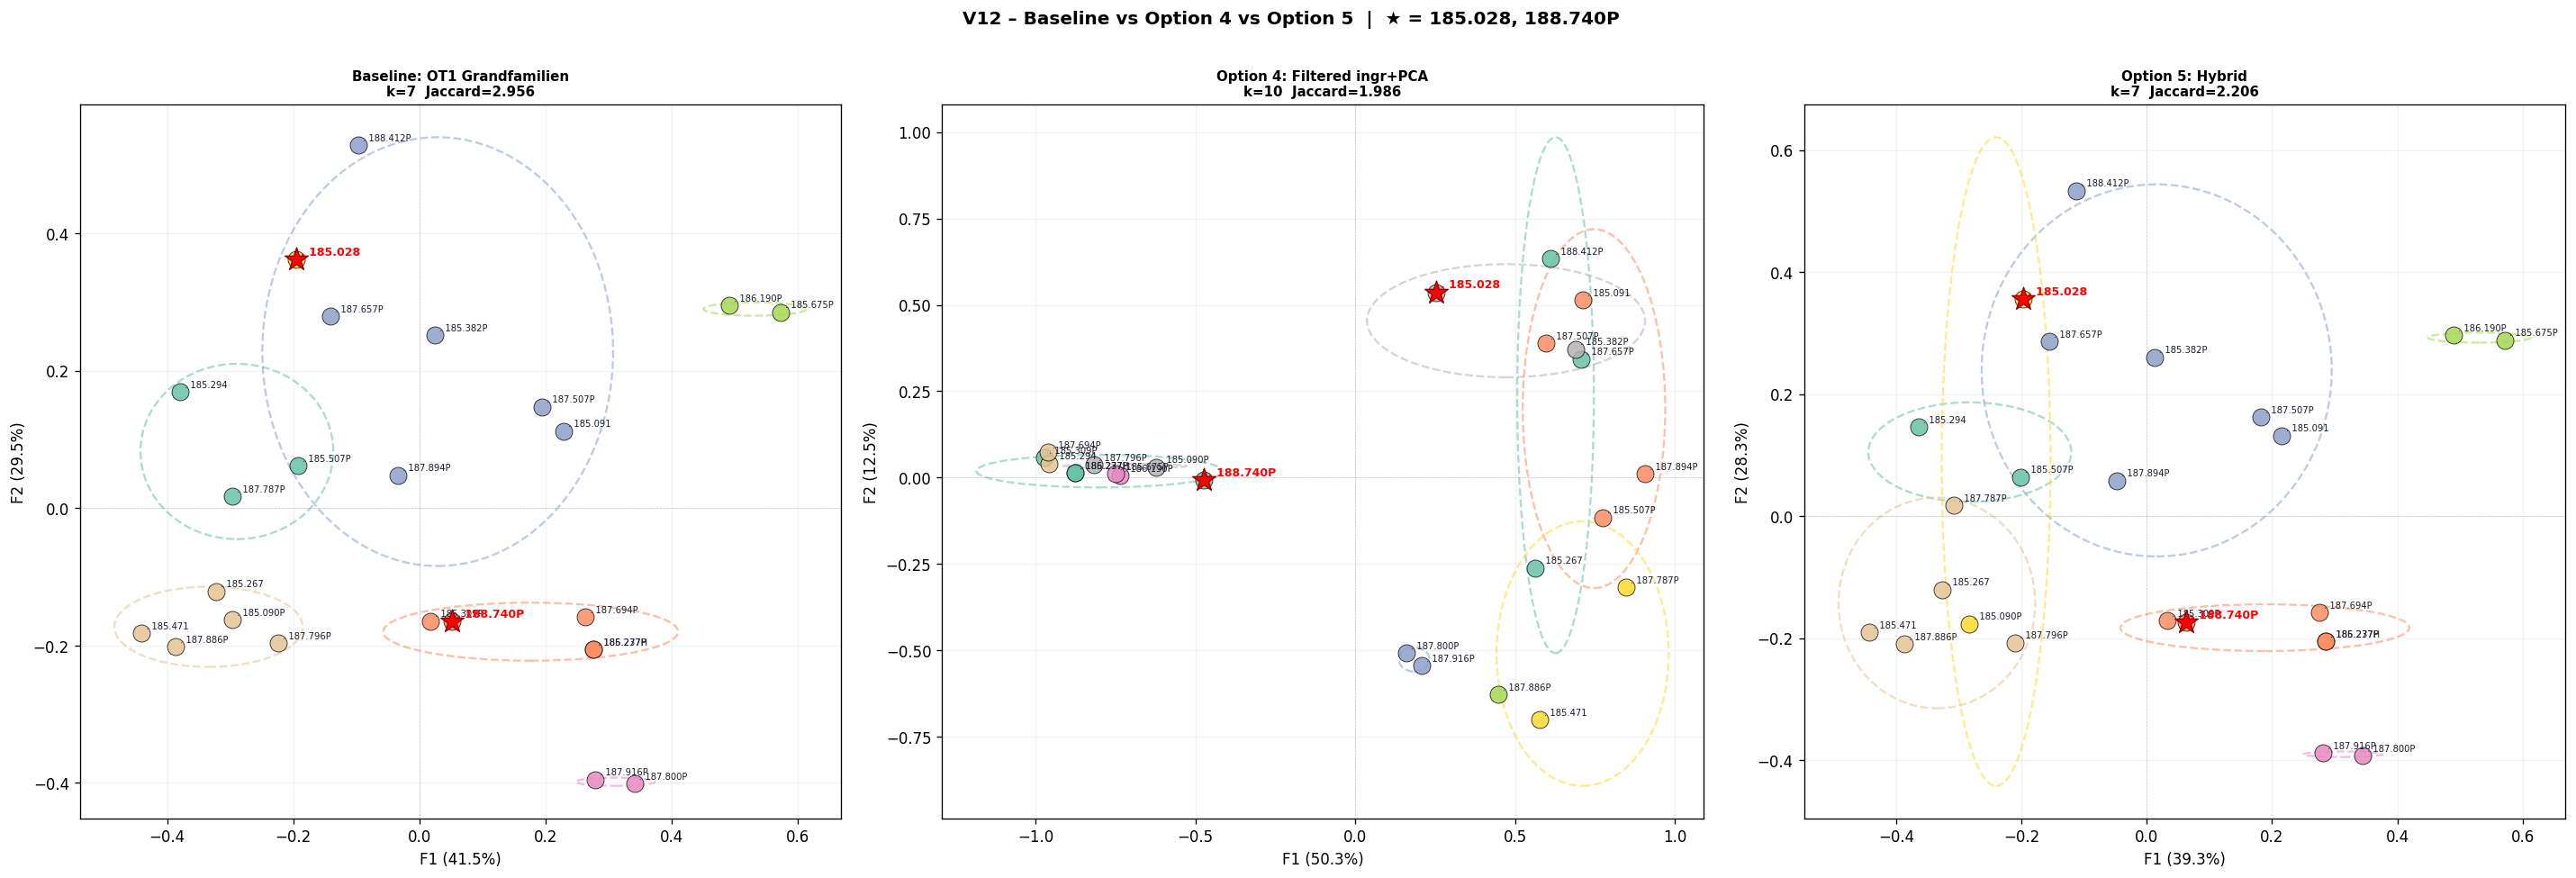

Saved → v12_comparison.png


In [11]:
# PCA scatter for all three approaches side-by-side
from sklearn.decomposition import PCA as PCA2D

FOCUS = ['185.028', '188.740P']

def get_2d_coords(X):
    p = PCA2D(n_components=2)
    return p.fit_transform(X), p.explained_variance_ratio_ * 100

# Best hybrid features for plotting
w1, w2 = best_weights
X_hybrid_best = np.hstack([normalize(X_ot1)*w1, normalize(X_pca4)*w2])
X_hybrid_best = normalize(X_hybrid_best)

plot_data = [
    ('Baseline: OT1 Grandfamilien',   X_ot1,          lbl_base, j_base, k_base),
    (f'Option 4: Filtered ingr+PCA',  normalize(pca4_best.transform(X_ingr)), lbl4, j4, k4),
    (f'Option 5: Hybrid',             X_hybrid_best,  lbl5,     j5,     k5),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (title, X, labels, j_score, k_val) in zip(axes, plot_data):
    coords, ve = get_2d_coords(X)
    clrs = plt.cm.Set2(np.linspace(0, 1, max(len(set(labels)), 8)))

    for lbl in sorted(set(labels)):
        mask = labels == lbl
        pts  = coords[mask]
        c    = clrs[lbl % len(clrs)]
        ax.scatter(pts[:,0], pts[:,1], c=[c], s=130, alpha=0.85,
                   edgecolors='black', lw=0.5, zorder=3)
        if len(pts) > 1:
            from matplotlib.patches import Ellipse
            cen = pts.mean(0)
            std = pts.std(0) + 1e-9
            ax.add_patch(Ellipse(xy=cen, width=std[0]*4, height=std[1]*4,
                                 edgecolor=c, fc='none', lw=1.4, ls='--', alpha=0.55))

    for i, rec in enumerate(recipes):
        x, y     = coords[i]
        is_focus = rec in FOCUS
        ax.annotate(f'. {rec}', (x,y), xytext=(3,3), textcoords='offset points',
                    fontsize=7.5 if is_focus else 6,
                    fontweight='bold' if is_focus else 'normal',
                    color='red' if is_focus else '#1a1a2e')
        if is_focus:
            ax.scatter(x, y, marker='*', s=260, c='red', zorder=6,
                       edgecolors='darkred', lw=0.8)

    ax.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.set_xlabel(f'F1 ({ve[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'F2 ({ve[1]:.1f}%)', fontsize=10)
    ax.set_title(f'{title}\nk={k_val}  Jaccard={j_score:.3f}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.15)

plt.suptitle('V12 – Baseline vs Option 4 vs Option 5  |  ★ = 185.028, 188.740P',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v12_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → v12_comparison.png')